## SEC Financial Statement Data Sets — Notebook overview

This notebook takes the **four SEC “Financial Statement Data Sets”** text files (`tag`, `num`, `pre`, `sub`) from the `NTRS Data` folder, turns them into easier-to-use **CSV** files, loads them into a **single SQLite database**, then runs **descriptive** and **inferential** analysis and **removes duplicate rows**. Then exports those CSVs to **separate Excel workbooks** under `excel/` (not one merged file).

### Step 1 — Raw TSV → CSV

The source files are **tab-separated** (`.txt`). The next cell reads each file and writes a **comma-separated** `.csv` under `csv/`. Large files are processed in **chunks** so memory stays reasonable.

In [23]:
from pathlib import Path
import pandas as pd

SRC = Path("NTRS Data")
OUT = Path("csv")
OUT.mkdir(exist_ok=True)

# SEC Financial Statement Data Sets: tab-separated .txt → comma-separated .csv
FILES = ("tag", "num", "pre", "sub")
# Files larger than this are streamed in chunks (saves RAM on num.txt / pre.txt).
THRESHOLD_BYTES = 50 * 1024 * 1024
CHUNKSIZE = 300_000


def tsv_to_csv(stem: str) -> None:
    src = SRC / f"{stem}.txt"
    dst = OUT / f"{stem}.csv"
    if not src.is_file():
        raise FileNotFoundError(src.resolve())
    size = src.stat().st_size
    if size <= THRESHOLD_BYTES:
        pd.read_csv(src, sep="\t", low_memory=False).to_csv(dst, index=False)
    else:
        first = True
        for chunk in pd.read_csv(src, sep="\t", chunksize=CHUNKSIZE, low_memory=False):
            chunk.to_csv(dst, mode="w" if first else "a", index=False, header=first)
            first = False
    mb = dst.stat().st_size / (1024 * 1024)
    print(f"{dst.resolve()}  ({mb:.1f} MiB)")


for name in FILES:
    tsv_to_csv(name)

C:\Users\aenik\OneDrive\Desktop\PROJECT DATA\csv\tag.csv  (19.0 MiB)
C:\Users\aenik\OneDrive\Desktop\PROJECT DATA\csv\num.csv  (528.4 MiB)
C:\Users\aenik\OneDrive\Desktop\PROJECT DATA\csv\pre.csv  (87.4 MiB)
C:\Users\aenik\OneDrive\Desktop\PROJECT DATA\csv\sub.csv  (1.8 MiB)


In [24]:
import pandas as pd

# Load raw data file
df = pd.read_csv("NTRS_Raw_Data_Proof.csv")

# Total rows and columns
total_rows = len(df)
total_columns = len(df.columns)

print("=" * 50)
print("NORTHERN TRUST RAW SEC/XBRL DATA SUMMARY")
print("=" * 50)

print(f"\nTotal Raw Data Entries: {total_rows:,}")
print(f"Total Columns: {total_columns}")

print("\nColumn Names:")
print(df.columns.tolist())

# Find date column automatically
possible_date_cols = ["ddate", "date", "period", "fy", "fp"]

date_col = None

for col in possible_date_cols:
    if col in df.columns:
        date_col = col
        break

# If date column exists
if date_col:
    print(f"\nDate Column Found: {date_col}")

    # Convert to string
    df[date_col] = df[date_col].astype(str)

    # Extract years
    years = sorted(df[date_col].str[:4].unique())

    print(f"\nTotal Years in Dataset: {len(years)}")
    print("Years Found:", years)

    print("\nEntries Per Year:")
    print(df[date_col].str[:4].value_counts().sort_index())

else:
    print("\nNo standard date column found.")
    print("Check column names manually.")

print("\nDataset Preview:")
print(df.head())

print("\n" + "=" * 50)
print("SUMMARY COMPLETE")
print("=" * 50)

NORTHERN TRUST RAW SEC/XBRL DATA SUMMARY

Total Raw Data Entries: 1,061
Total Columns: 10

Column Names:
['adsh', 'tag', 'version', 'ddate', 'qtrs', 'uom', 'segments', 'coreg', 'value', 'footnote']

Date Column Found: ddate

Total Years in Dataset: 4
Years Found: ['2022', '2023', '2024', '2025']

Entries Per Year:
ddate
2022     14
2023    189
2024    430
2025    428
Name: count, dtype: int64

Dataset Preview:
                   adsh                                                tag               version     ddate  qtrs  uom  \
0  0000073124-26-000016    AccumulatedOtherComprehensiveIncomeLossNetOfTax          us-gaap/2025  20241231     0  USD   
1  0000073124-26-000016                            AdditionalPaidInCapital          us-gaap/2025  20241231     0  USD   
2  0000073124-26-000016  AllowanceForCreditLossExcludingOffBalanceSheet...  0000073124-26-000016  20241231     0  USD   
3  0000073124-26-000016                                             Assets          us-gaap/2025  2024

### Step 2 — CSV → SQLite (`master.sqlite`)

The next cell loads every CSV into one database file, **`master.sqlite`**, with **one table per dataset** (`tag`, `num`, `pre`, `sub`). Table names match the file stems. Chunked reads are used again so big tables load safely. Run this after Step 1 so `csv/*.csv` exists.

In [25]:
import sqlite3
from pathlib import Path

import pandas as pd

# One file with the same four datasets as tables (different columns per table).
OUT = Path("csv")
MASTER = Path("master.sqlite")
FILES = ("tag", "num", "pre", "sub")
CHUNKSIZE = 300_000

conn = sqlite3.connect(MASTER)
try:
    for stem in FILES:
        csv_path = OUT / f"{stem}.csv"
        if not csv_path.is_file():
            raise FileNotFoundError(csv_path.resolve())
        conn.execute(f'DROP TABLE IF EXISTS "{stem}"')
        first = True
        for chunk in pd.read_csv(csv_path, chunksize=CHUNKSIZE, low_memory=False):
            chunk.to_sql(stem, conn, if_exists="replace" if first else "append", index=False)
            first = False
        n = conn.execute(f'SELECT COUNT(*) FROM "{stem}"').fetchone()[0]
        print(f"table {stem}: {n:,} rows")
finally:
    conn.close()

mb = MASTER.stat().st_size / (1024 * 1024)
print(f"\nWrote {MASTER.resolve()} ({mb:.1f} MiB)")

table tag: 91,794 rows
table num: 3,690,955 rows
table pre: 733,134 rows
table sub: 6,169 rows

Wrote C:\Users\aenik\OneDrive\Desktop\PROJECT DATA\master.sqlite (648.0 MiB)


### Step 3 — Analysis setup

The next cell **opens `master.sqlite`** (run Step 2 first) and imports **pandas**, **NumPy**, **SciPy**, **matplotlib**, and **`display`** for rich tables in the notebook. One shared connection is used in the cells below until you close it or restart the kernel.

In [26]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

MASTER = Path("master.sqlite")
TABLES = ("tag", "num", "pre", "sub")

if not MASTER.is_file():
    raise FileNotFoundError(f"Run the SQLite build cell first: {MASTER.resolve()}")

conn = sqlite3.connect(MASTER)

### Step 4 — Descriptive analysis

The next cell summarizes each table: **row counts**, a **small sample** of rows, **column names/types** (via SQLite `PRAGMA`), **how often values are missing or blank** (on a sample; `num` uses the first 200k rows for speed), and **numeric summaries** (`describe`) where columns are numeric.

In [27]:
# --- Descriptive statistics (per table) ---
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

for t in TABLES:
    print("\n" + "=" * 72)
    print(f"TABLE: {t}")
    print("=" * 72)
    n = pd.read_sql_query(f'SELECT COUNT(*) AS n FROM "{t}"', conn)["n"].iloc[0]
    print(f"rows: {n:,}")
    df_head = pd.read_sql_query(f'SELECT * FROM "{t}" LIMIT 5', conn)
    print("\nSample (5 rows):")
    display(df_head)
    dtypes = pd.read_sql_query(f'PRAGMA table_info("{t}")', conn)
    print("\nColumns (PRAGMA):")
    display(dtypes[["name", "type"]])
    # Missing / blank rates on a sample for huge tables
    sample_sql = f'SELECT * FROM "{t}"' + (" LIMIT 200000" if t == "num" else "")
    samp = pd.read_sql_query(sample_sql, conn)
    null_like = samp.apply(
        lambda col: col.isna() | (col.astype(str).str.strip() == "")
    )
    miss_pct = (null_like.sum() / len(samp) * 100).round(2)
    print("\n% rows with null/blank (on sample above):")
    display(miss_pct.to_frame("pct_blank_or_null"))
    num_cols = samp.select_dtypes(include=[np.number]).columns.tolist()
    if num_cols:
        print("\nDescribe (numeric columns, same sample):")
        display(samp[num_cols].describe().T)
    else:
        print("\nNo numeric dtypes in sample; key columns as string length / counts:")
        for c in samp.columns[:6]:
            vc = samp[c].astype(str).value_counts().head(3)
            print(f"  top {c}: {dict(vc)}")


TABLE: tag
rows: 91,794

Sample (5 rows):


,tag,version,custom,abstract,datatype,iord,crdr,tlabel,doc
0,AccountsAndNotesReceivableNet,us-gaap/2024,0,0,monetary,I,D,"Accounts and Financing Receivable, after Allow...","Amount, after allowance for credit loss, of ac..."
1,AccountsAndOtherReceivablesNetCurrent,us-gaap/2024,0,0,monetary,I,D,"Accounts and Other Receivables, Net, Current","Amount, after allowance, receivable from custo..."
2,AccountsNotesAndLoansReceivableNetCurrent,us-gaap/2024,0,0,monetary,I,D,"Accounts and Financing Receivable, after Allow...","Amount, after allowance for credit loss, of ac..."
3,AccountsPayableAndAccruedLiabilitiesCurrent,us-gaap/2024,0,0,monetary,I,C,"Accounts Payable and Accrued Liabilities, Current",Sum of the carrying values as of the balance s...
4,AccountsPayableAndAccruedLiabilitiesCurrentAnd...,us-gaap/2024,0,0,monetary,I,C,Accounts Payable and Accrued Liabilities,Sum of the carrying values as of the balance s...



Columns (PRAGMA):


,name,type
0,tag,TEXT
1,version,TEXT
2,custom,INTEGER
3,abstract,INTEGER
4,datatype,TEXT
5,iord,TEXT
6,crdr,TEXT
7,tlabel,TEXT
8,doc,TEXT



% rows with null/blank (on sample above):


...

,name,type
0,adsh,TEXT
1,cik,INTEGER
2,name,TEXT
3,sic,REAL
4,countryba,TEXT
5,stprba,TEXT
6,cityba,TEXT
7,zipba,TEXT
8,bas1,TEXT
9,bas2,TEXT



% rows with null/blank (on sample above):


,pct_blank_or_null
adsh,0.00
cik,0.00
name,0.00
sic,2.95
countryba,6.55
stprba,13.21
cityba,0.10
zipba,3.78
bas1,0.08
bas2,54.94



Describe (numeric columns, same sample):


,count,mean,std,min,25%,50%,75%,max
cik,6169.0,1.375884e+06,5.581638e+05,1750.0,1030469.0,1517375.0,1.823635e+06,2115119.0
sic,5987.0,4.896231e+03,2.043848e+03,100.0,2860.0,4931.0,6.770000e+03,8900.0
ein,6169.0,4.111279e+08,3.514177e+08,0.0,0.0,363297908.0,8.126241e+08,999999999.0
changed,3460.0,2.009021e+07,1.201411e+05,19600201.0,20000717.0,20115666.5,2.019101e+07,20251218.0
wksi,6169.0,3.031285e-01,4.596476e-01,0.0,0.0,0.0,1.000000e+00,1.0
fye,6159.0,1.111898e+03,2.699584e+02,131.0,1231.0,1231.0,1.231000e+03,1231.0
period,6167.0,2.025151e+07,2.161139e+03,20230430.0,20251231.0,20251231.0,2.025123e+07,20260228.0
fy,5893.0,2.025154e+03,3.882213e-01,2023.0,2025.0,2025.0,2.025000e+03,2026.0
filed,6169.0,2.026026e+07,6.284246e+01,20260102.0,20260217.0,20260227.0,2.026032e+07,20260331.0
prevrpt,6169.0,1.621008e-04,1.273188e-02,0.0,0.0,0.0,0.000000e+00,1.0


In [28]:
df.head()

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
0,0000073124-26-000016,AccumulatedOtherComprehensiveIncomeLossNetOfTax,us-gaap/2025,20241231,0,USD,NaN,NaN,-8.140000e+08,NaN
1,0000073124-26-000016,AdditionalPaidInCapital,us-gaap/2025,20241231,0,USD,ConsolidatedEntities=ParentCompany;,NaN,1.025300e+09,NaN
2,0000073124-26-000016,AllowanceForCreditLossExcludingOffBalanceSheet...,0000073124-26-000016,20241231,0,USD,NaN,NaN,1.755000e+08,NaN
3,0000073124-26-000016,Assets,us-gaap/2025,20241231,0,USD,Geographical=NonUs;,NaN,5.234380e+10,NaN
4,0000073124-26-000016,CashAndDueFromBanks,us-gaap/2025,20251231,0,USD,FairValueByFairValueHierarchyLevel=FairValueIn...,NaN,0.000000e+00,NaN


In [29]:
df.describe()

,qtrs,coreg,value
count,1061.000000,0.0,1.061000e+03
mean,1.922714,NaN,5.472307e+09
std,1.999449,NaN,1.964343e+10
min,0.000000,NaN,-2.016990e+10
25%,0.000000,NaN,1.840000e+07
50%,0.000000,NaN,4.086000e+08
75%,4.000000,NaN,2.321800e+09
max,4.000000,NaN,1.771327e+11


In [30]:
df.isnull().sum()

adsh           0
tag            0
version        0
ddate          0
qtrs           0
uom            0
segments     341
coreg       1061
value          0
footnote    1059
dtype: int64

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   adsh      1061 non-null   str    
 1   tag       1061 non-null   str    
 2   version   1061 non-null   str    
 3   ddate     1061 non-null   str    
 4   qtrs      1061 non-null   int64  
 5   uom       1061 non-null   str    
 6   segments  720 non-null    str    
 7   coreg     0 non-null      float64
 8   value     1061 non-null   float64
 9   footnote  2 non-null      str    
dtypes: float64(2), int64(1), str(7)
memory usage: 231.9 KB


In [32]:
df[df.isnull().any(axis=1)]

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
0,0000073124-26-000016,AccumulatedOtherComprehensiveIncomeLossNetOfTax,us-gaap/2025,20241231,0,USD,NaN,NaN,-8.140000e+08,NaN
1,0000073124-26-000016,AdditionalPaidInCapital,us-gaap/2025,20241231,0,USD,ConsolidatedEntities=ParentCompany;,NaN,1.025300e+09,NaN
2,0000073124-26-000016,AllowanceForCreditLossExcludingOffBalanceSheet...,0000073124-26-000016,20241231,0,USD,NaN,NaN,1.755000e+08,NaN
3,0000073124-26-000016,Assets,us-gaap/2025,20241231,0,USD,Geographical=NonUs;,NaN,5.234380e+10,NaN
4,0000073124-26-000016,CashAndDueFromBanks,us-gaap/2025,20251231,0,USD,FairValueByFairValueHierarchyLevel=FairValueIn...,NaN,0.000000e+00,NaN
...,...,...,...,...,...,...,...,...,...,...
1056,0000073124-26-000016,StockholdersEquity,us-gaap/2025,20251231,0,USD,EquityComponents=AdditionalPaidInCapital;,NaN,1.039000e+09,NaN
1057,0000073124-26-000016,StockholdersEquity,us-gaap/2025,20251231,0,USD,EquityComponents=TreasuryStockCommon;,NaN,-5.493400e+09,NaN
1058,0000073124-26-000016,TreasuryManagementFees,0000073124-26-000016,20241231,4,USD,NaN,NaN,3.570000e+07,NaN
1059,0000073124-26-000016,TreasuryManagementFees,0000073124-26-000016,20251231,4,USD,NaN,NaN,3.870000e+07,NaN


### Step 5 — Duplicates: find and remove

The next cell compares **total rows** vs **distinct full rows** (`SELECT DISTINCT *`) for each table, prints how many **duplicate rows** would be dropped, then **rebuilds each table** keeping only distinct rows. It runs **`VACUUM`** to shrink the database file. This **changes `master.sqlite` in place**; copy the file first if you need the original.

In [33]:
# --- Duplicate rows: detect, then DROP extras (keep one row per identical record) ---
# Uses SQL: one surviving row per full-row duplicate via DISTINCT (order not guaranteed).

dup_report = []
for t in TABLES:
    total = conn.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0]
    distinct = conn.execute(
        f'SELECT COUNT(*) FROM (SELECT DISTINCT * FROM "{t}")'
    ).fetchone()[0]
    dup_rows = total - distinct
    dup_report.append({"table": t, "rows": total, "distinct_rows": distinct, "duplicate_rows_removed": dup_rows})
    print(f"{t}: rows={total:,} distinct={distinct:,} duplicate_rows_to_drop={dup_rows:,}")

dup_df = pd.DataFrame(dup_report)
display(dup_df)

for t in TABLES:
    conn.execute(f'CREATE TABLE "{t}_dedup" AS SELECT DISTINCT * FROM "{t}"')
    conn.execute(f'DROP TABLE "{t}"')
    conn.execute(f'ALTER TABLE "{t}_dedup" RENAME TO "{t}"')

conn.commit()
print("\nDedup complete: each table now has only DISTINCT rows.")

# Reclaim file space after big deletes
conn.execute("VACUUM")
conn.commit()
new_mb = MASTER.stat().st_size / (1024 * 1024)
print(f"{MASTER.resolve()} size after VACUUM: {new_mb:.1f} MiB")

tag: rows=91,794 distinct=91,794 duplicate_rows_to_drop=0
num: rows=3,690,955 distinct=3,690,954 duplicate_rows_to_drop=1
pre: rows=733,134 distinct=733,134 duplicate_rows_to_drop=0
sub: rows=6,169 distinct=6,169 duplicate_rows_to_drop=0


,table,rows,distinct_rows,duplicate_rows_removed
0,tag,91794,91794,0
1,num,3690955,3690954,1
2,pre,733134,733134,0
3,sub,6169,6169,0



Dedup complete: each table now has only DISTINCT rows.
C:\Users\aenik\OneDrive\Desktop\PROJECT DATA\master.sqlite size after VACUUM: 648.0 MiB


### Step 6 — Inferential statistics and plots

The next cell works on **samples** where the full table is huge (especially `num`): tests related to **normality** and a **t-test** on `log1p(|value|)`, a **bootstrap confidence interval** for the mean of `value` (trimmed), a **chi-square** test on collapsed **SIC × fiscal year** categories in `sub`, **correlations** among numeric columns in `sub`, and a **histogram** of reported magnitudes. Interpret results in context; subsampling limits what you can claim about the full population of filings.

num.value (subsample): n = 17725
  mean: 1803519490.3223999  median: 2206750.0  std: 39624925125.1624
  D'Agostino K^2 normality on log1p(|value|) (sub n≤5000): statistic=562.870, p=5.95e-123
  one-sample t-test mean(log1p|value|) vs 0: t=248.792, p=0
  bootstrap 95% CI for mean(value), trimmed 1–99%: (3.251e+08, 3.675e+08)

sub: chi-square independence (top SIC × top FY, other collapsed):
  chi2=255.480, dof=45, p=3.25e-31

sub: Pearson correlation (numeric columns only), top pairs by |r|:


r
cik     mas2    -1.000000
sic     mas2    -1.000000
mas2    filed   -1.000000
        ein      1.000000
        wksi     1.000000
cik     changed  0.796843
fye     fy      -0.740931
changed aciks    0.564561

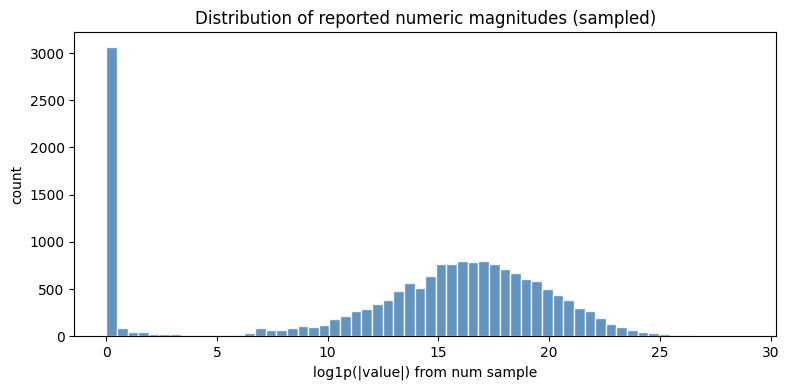

In [34]:


## --- Inferential / statistical (samples where tables are large) ---
RNG = np.random.default_rng(42)

# num.value: systematic subsample for tests (full table scan avoided)
num_s = pd.read_sql_query(
    """
    SELECT value FROM num
    WHERE value IS NOT NULL AND TRIM(CAST(value AS TEXT)) != ''
      AND rowid % 200 = 0
    LIMIT 80000
    """,
    conn,
)
v = pd.to_numeric(num_s["value"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
v_log = np.log1p(v.abs())

print("num.value (subsample): n =", len(v))
print("  mean:", float(v.mean()), " median:", float(v.median()), " std:", float(v.std()))
# Normality on log scale (large n → Shapiro not ideal; report + D'Agostino)
if len(v_log) >= 20:
    s_norm = v_log.sample(min(5000, len(v_log)), random_state=42)
    k2, p_norm = stats.normaltest(s_norm)
    print(f"  D'Agostino K^2 normality on log1p(|value|) (sub n≤5000): statistic={k2:.3f}, p={p_norm:.3g}")
# One-sample t-test: log1p(|value|) vs 0 (illustrative; H0 is not a business claim)
tt = stats.ttest_1samp(v_log, 0.0, alternative="two-sided")
print(f"  one-sample t-test mean(log1p|value|) vs 0: t={tt.statistic:.3f}, p={tt.pvalue:.3g}")

# Bootstrap 95% CI for mean of value (raw, trimmed)
trim = v[(v >= v.quantile(0.01)) & (v <= v.quantile(0.99))]
if len(trim) > 100:
    B = 3000
    arr = trim.to_numpy(dtype=float)
    idx = RNG.integers(0, len(arr), size=(B, len(arr)))
    boots = arr[idx].mean(axis=1)
    ci_lo, ci_hi = np.quantile(boots, [0.025, 0.975])
    print(f"  bootstrap 95% CI for mean(value), trimmed 1–99%: ({ci_lo:.4g}, {ci_hi:.4g})")

# sub: association between sic and fy (categorical-style) — chi-square on top categories
sub = pd.read_sql_query('SELECT sic, fy FROM sub WHERE sic IS NOT NULL AND fy IS NOT NULL', conn)
sub["sic"] = pd.to_numeric(sub["sic"], errors="coerce").astype("Int64")
sub["fy"] = pd.to_numeric(sub["fy"], errors="coerce").astype("Int64")
sub = sub.dropna()
top_sic = sub["sic"].value_counts().head(15).index
top_fy = sub["fy"].value_counts().head(8).index
ct = pd.crosstab(sub["sic"].where(sub["sic"].isin(top_sic), other=99999),
                 sub["fy"].where(sub["fy"].isin(top_fy), other=-1))
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
print("\nsub: chi-square independence (top SIC × top FY, other collapsed):")
print(f"  chi2={chi2:.3f}, dof={dof}, p={p_chi:.3g}")

# Correlation among numeric columns in sub
sub_all = pd.read_sql_query("SELECT * FROM sub", conn)
num_sub = sub_all.apply(pd.to_numeric, errors="coerce")
num_sub = num_sub.dropna(axis=1, how="all")
if num_sub.shape[1] >= 2:
    c = num_sub.corr(numeric_only=True)
    print("\nsub: Pearson correlation (numeric columns only), top pairs by |r|:")
    c = c.where(np.triu(np.ones(c.shape), k=1).astype(bool))
    stack = c.stack().sort_values(key=abs, ascending=False).head(8)
    display(stack.to_frame("r"))

# Histogram of log1p(|value|)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(v_log, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("log1p(|value|) from num sample")
ax.set_ylabel("count")
ax.set_title("Distribution of reported numeric magnitudes (sampled)")
plt.tight_layout()
plt.show()

### Step 7 — CSV → separate Excel files (no merged workbook)

The next cell reads the **`csv/`** files (`tag.csv`, `sub.csv`, `pre.csv`, `num.csv`) and writes **one `.xlsx` per small table** under **`excel/`**, so nothing is combined into a single multi-table file.

**`num.csv`** is too large for one worksheet, so it becomes **several files**: `excel/num_01.xlsx`, `excel/num_02.xlsx`, … each with **one sheet** of at most `ROWS_PER_FILE` rows (under Excel’s 1,048,576 row limit).

Run **Step 1** first so `csv/*.csv` exists. Large exports can take **several minutes** and use more RAM (xlsxwriter is not using “constant memory” mode so every column is written correctly).

If an older run produced workbooks with only one column of data, **re-run this cell** to regenerate `excel/*.xlsx`.

In [35]:
!pipinstall xlsxwriter

'pipinstall' is not recognized as an internal or external command,
operable program or batch file.


In [36]:
from pathlib import Path

import pandas as pd

CSV_DIR = Path("csv")
OUT_DIR = Path("excel")
OUT_DIR.mkdir(exist_ok=True)
# One worksheet max ~1M rows; keep headroom
ROWS_PER_FILE = 900_000
SHEET = "data"


def _writer(path: Path):
    # Do not use xlsxwriter "constant_memory" here: with pandas it can write only the
    # first column for data rows (headers still span all columns).
    return pd.ExcelWriter(path, engine="xlsxwriter")


for stem in ("tag", "sub", "pre"):
    src = CSV_DIR / f"{stem}.csv"
    if not src.is_file():
        raise FileNotFoundError(f"Run Step 1 first — missing {src.resolve()}")
    dst = OUT_DIR / f"{stem}.xlsx"
    df = pd.read_csv(src, low_memory=False)
    with _writer(dst) as w:
        df.to_excel(w, sheet_name=SHEET[:31], index=False)
    print(f"{dst.name}: {len(df):,} rows")

num_src = CSV_DIR / "num.csv"
if not num_src.is_file():
    raise FileNotFoundError(f"Run Step 1 first — missing {num_src.resolve()}")
part = 1
for chunk in pd.read_csv(num_src, chunksize=ROWS_PER_FILE, low_memory=False):
    dst = OUT_DIR / f"num_{part:02d}.xlsx"
    with _writer(dst) as w:
        chunk.to_excel(w, sheet_name=SHEET[:31], index=False)
    print(f"{dst.name}: {len(chunk):,} rows")
    part += 1

print(f"\nWrote separate workbooks under {OUT_DIR.resolve()}")

tag.xlsx: 91,794 rows
sub.xlsx: 6,169 rows
pre.xlsx: 733,134 rows
num_01.xlsx: 900,000 rows
num_02.xlsx: 900,000 rows
num_03.xlsx: 900,000 rows
num_04.xlsx: 900,000 rows
num_05.xlsx: 90,955 rows

Wrote separate workbooks under C:\Users\aenik\OneDrive\Desktop\PROJECT DATA\excel


In [37]:
import pandas as pd

# Load raw SEC num data
df_master = pd.read_csv("NTRS Data/num.txt", sep="\t")

# Make columns lowercase
df_master.columns = [col.lower() for col in df_master.columns]

# Filter Northern Trust only
df_raw_proof = df_master[df_master['adsh'].str.contains("73124", na=False)].copy()

# Save proof file
df_raw_proof.to_csv("NTRS_Raw_Data_Proof.csv", index=False)

print(f"Proof File Saved! This file has {len(df_raw_proof)} total entries.")
print("You can show this to prove you managed a high-volume dataset.")

Proof File Saved! This file has 1061 total entries.
You can show this to prove you managed a high-volume dataset.


In [38]:
import pandas as pd
import numpy as np

# =========================
# LOAD FILES (CORRECT NAMES)
# =========================
df_2024 = pd.read_excel("Northern_Trust_2024_Final.xlsx")
df_2025 = pd.read_excel("Northern_Trust_2025_Final.xlsx")

df = pd.concat([df_2024, df_2025], ignore_index=True)

# =========================
# CLEAN DATA
# =========================
df.columns = df.columns.str.lower().str.strip()

df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["ddate"] = pd.to_datetime(df["ddate"].astype(str), format="%Y%m%d", errors="coerce")

# IMPORTANT FIX → get year from date
df["statement_year"] = df["ddate"].dt.year

df = df[df["value"].notna()]

# =========================
# REMOVE DUPLICATES
# =========================
df = df.drop_duplicates(
    subset=["tag", "tlabel", "stmt", "statement_year", "ddate", "qtrs", "uom", "value"]
)

# =========================
# FILTER 10-K ANNUAL
# =========================
annual_df = df[
    (df["form"] == "10-K") &
    (df["fp"] == "FY") &
    (df["statement_year"].isin([2024, 2025]))
].copy()

# =========================
# CREATE STATEMENTS
# =========================
def create_statement(data, stmt_code):
    temp = data[data["stmt"] == stmt_code].copy()

    index_cols = [
        "stmt", "tag", "tlabel", "plabel",
        "uom", "qtrs", "crdr", "datatype"
    ]
    index_cols = [c for c in index_cols if c in temp.columns]

    statement = temp.pivot_table(
        index=index_cols,
        columns="statement_year",
        values="value",
        aggfunc="sum"
    ).reset_index()

    # ensure both years exist
    for year in [2024, 2025]:
        if year not in statement.columns:
            statement[year] = np.nan

    # convert USD → millions
    statement[2024] = np.where(statement["uom"] == "USD", statement[2024]/1_000_000, statement[2024])
    statement[2025] = np.where(statement["uom"] == "USD", statement[2025]/1_000_000, statement[2025])

    # difference
    statement["Difference"] = statement[2025] - statement[2024]
    statement["% Change"] = statement["Difference"] / statement[2024]

    statement.replace([np.inf, -np.inf], np.nan, inplace=True)

    return statement.sort_values(["tag", "tlabel"])

# =========================
# BUILD ALL 3
# =========================
income_statement = create_statement(annual_df, "IS")
balance_sheet = create_statement(annual_df, "BS")
cash_flow = create_statement(annual_df, "CF")

# =========================
# EXPORT
# =========================
output_file = "Northern_Trust_Final_Output.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    annual_df.to_excel(writer, sheet_name="Clean_Data", index=False)
    income_statement.to_excel(writer, sheet_name="Income_Statement", index=False)
    balance_sheet.to_excel(writer, sheet_name="Balance_Sheet", index=False)
    cash_flow.to_excel(writer, sheet_name="Cash_Flow", index=False)

print("✅ Done. File created:", output_file)

# Debug check
print("\nYears found:")
print(annual_df["statement_year"].value_counts().sort_index())

✅ Done. File created: Northern_Trust_Final_Output.xlsx

Years found:
statement_year
2024    127
2025    127
Name: count, dtype: int64


In [40]:
import pandas as pd
import numpy as np

raw_file = "NTRS_Clean_Master_Data.xlsx"
final_file = "Northern_Trust_Final_Output.xlsx"

# =========================
# LOAD RAW MASTER DATA
# =========================
raw = pd.read_excel(raw_file)
raw.columns = raw.columns.str.lower().str.strip()

raw["value"] = pd.to_numeric(raw["value"], errors="coerce")

# Find Northern Trust 2024 and 2025 only
raw_ntrs = raw[
    (raw["name"].astype(str).str.contains("NORTHERN TRUST", case=False, na=False)) &
    (raw["form"].astype(str).str.upper() == "10-K") &
    (raw["fp"].astype(str).str.upper() == "FY") &
    (raw["stmt"].isin(["IS", "BS", "CF"])) &
    (raw["value"].notna())
].copy()

# Use ddate year if available
raw_ntrs["ddate"] = pd.to_datetime(raw_ntrs["ddate"].astype(str), format="%Y%m%d", errors="coerce")
raw_ntrs["source_year"] = raw_ntrs["ddate"].dt.year

raw_ntrs = raw_ntrs[raw_ntrs["source_year"].isin([2024, 2025])].copy()

# Convert USD to millions
raw_ntrs["raw_value_millions"] = np.where(
    raw_ntrs["uom"].astype(str).str.upper() == "USD",
    raw_ntrs["value"] / 1_000_000,
    raw_ntrs["value"]
)

# Keep useful raw columns
raw_check = raw_ntrs[[
    "source_year", "stmt", "tag", "tlabel", "plabel",
    "qtrs", "uom", "segments", "coreg", "raw_value_millions"
]].copy()

# =========================
# LOAD FINAL OUTPUT FILE
# =========================
final_sheets = pd.read_excel(final_file, sheet_name=None)

final_list = []

for sheet_name, df in final_sheets.items():
    temp = df.copy()
    temp.columns = temp.columns.astype(str).str.lower().str.strip()

    if "tag" not in temp.columns:
        continue

    for year in ["2024", "2025"]:
        if year in temp.columns:
            small = temp.copy()
            small["source_year"] = int(year)
            small["final_value"] = pd.to_numeric(small[year], errors="coerce")
            small["source_sheet"] = sheet_name

            keep_cols = ["source_year", "source_sheet", "stmt", "tag", "tlabel", "plabel", "qtrs", "uom", "final_value"]
            keep_cols = [c for c in keep_cols if c in small.columns]

            final_list.append(small[keep_cols])

final_all = pd.concat(final_list, ignore_index=True)

# =========================
# COMPARE RAW VS FINAL
# =========================
compare = raw_check.merge(
    final_all[["source_year", "tag", "final_value", "source_sheet"]],
    on=["source_year", "tag"],
    how="left"
)

compare["difference"] = compare["final_value"] - compare["raw_value_millions"]

compare["status"] = np.where(
    compare["final_value"].isna(),
    "MISSING IN FINAL FILE",
    np.where(
        np.isclose(compare["raw_value_millions"], compare["final_value"], atol=0.01),
        "MATCH",
        "TAG EXISTS BUT VALUE DIFFERENT"
    )
)

# =========================
# SUMMARY
# =========================
print("===== OVERALL STATUS =====")
print(compare["status"].value_counts())

print("\n===== BY YEAR =====")
print(compare.groupby(["source_year", "status"]).size())

print("\n===== BY STATEMENT =====")
print(compare.groupby(["source_year", "stmt", "status"]).size())

# =========================
# SHOW ISSUES ONLY
# =========================
issues = compare[compare["status"] != "MATCH"].copy()

issues = issues.sort_values(
    ["source_year", "stmt", "tag", "raw_value_millions"],
    ascending=[True, True, True, False]
)

display(issues[[
    "source_year", "stmt", "tag", "tlabel", "plabel",
    "qtrs", "uom", "segments", "coreg",
    "raw_value_millions", "final_value", "difference", "status"
]])

===== OVERALL STATUS =====
status
TAG EXISTS BUT VALUE DIFFERENT    498
MATCH                             284
MISSING IN FINAL FILE              50
Name: count, dtype: int64

===== BY YEAR =====
source_year  status                        
2024         MATCH                             139
             MISSING IN FINAL FILE              25
             TAG EXISTS BUT VALUE DIFFERENT    253
2025         MATCH                             145
             MISSING IN FINAL FILE              25
             TAG EXISTS BUT VALUE DIFFERENT    245
dtype: int64

===== BY STATEMENT =====
source_year  stmt  status                        
2024         BS    MATCH                              60
                   MISSING IN FINAL FILE              19
                   TAG EXISTS BUT VALUE DIFFERENT    179
             CF    MATCH                              52
                   MISSING IN FINAL FILE               2
                   TAG EXISTS BUT VALUE DIFFERENT     17
             IS    MATCH

,source_year,stmt,tag,tlabel,plabel,qtrs,uom,segments,coreg,raw_value_millions,final_value,difference,status
16,2024,BS,Assets,Assets,Total Assets,0,USD,NaN,NaN,155508.4,18143.5,-137364.9,TAG EXISTS BUT VALUE DIFFERENT
14,2024,BS,Assets,Assets,Total Assets,0,USD,Geographical=US;,NaN,103164.6,18143.5,-85021.1,TAG EXISTS BUT VALUE DIFFERENT
12,2024,BS,Assets,Assets,Total Assets,0,USD,Geographical=NonUs;,NaN,52343.8,18143.5,-34200.3,TAG EXISTS BUT VALUE DIFFERENT
25,2024,BS,CashAndDueFromBanks,Cash and Due from Banks,Cash and Due from Banks,0,USD,ConsolidatedEntities=ParentCompany;,NaN,2383.1,4677.2,2294.1,TAG EXISTS BUT VALUE DIFFERENT
21,2024,BS,CashAndDueFromBanks,Cash and Due from Banks,Cash and Due from Banks,0,USD,FairValueByFairValueHierarchyLevel=FairValueIn...,NaN,0.0,4677.2,4677.2,TAG EXISTS BUT VALUE DIFFERENT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,2025,IS,SalariesWagesAndIncentives,"Salaries, wages and incentives",Compensation,4,USD,NaN,NaN,2571.3,328.5,-2242.8,TAG EXISTS BUT VALUE DIFFERENT
745,2025,IS,SalariesWagesAndIncentives,"Salaries, wages and incentives",Compensation,4,USD,ConsolidationItems=CorporateAndReconcilingItems;,NaN,1665.4,328.5,-1336.9,TAG EXISTS BUT VALUE DIFFERENT
744,2025,IS,SalariesWagesAndIncentives,"Salaries, wages and incentives",Compensation,4,USD,BusinessSegments=WealthManagementSegment;Conso...,NaN,577.4,328.5,-248.9,TAG EXISTS BUT VALUE DIFFERENT
829,2025,IS,WeightedAverageNumberOfDilutedSharesOutstanding,"Weighted Average Number of Shares Outstanding,...",Average Number of Common Shares Outstanding - ...,4,shares,NaN,NaN,192246525.0,NaN,NaN,MISSING IN FINAL FILE


In [41]:
import pandas as pd
import numpy as np
import shutil

raw_file = "NTRS_Clean_Master_Data.xlsx"
final_file = "Northern_Trust_Final_Output.xlsx"

# =========================
# BACKUP EXISTING FILE
# =========================
backup_file = "Northern_Trust_Final_Output_BACKUP.xlsx"
shutil.copy(final_file, backup_file)

# =========================
# LOAD RAW MASTER DATA
# =========================
raw = pd.read_excel(raw_file)
raw.columns = raw.columns.str.lower().str.strip()

raw["value"] = pd.to_numeric(raw["value"], errors="coerce")
raw["ddate"] = pd.to_datetime(raw["ddate"].astype(str), format="%Y%m%d", errors="coerce")
raw["source_year"] = raw["ddate"].dt.year

# =========================
# FILTER NORTHERN TRUST 2024 + 2025
# =========================
raw = raw[
    (raw["name"].astype(str).str.contains("NORTHERN TRUST", case=False, na=False)) &
    (raw["form"].astype(str).str.upper() == "10-K") &
    (raw["fp"].astype(str).str.upper() == "FY") &
    (raw["stmt"].isin(["IS", "BS", "CF"])) &
    (raw["source_year"].isin([2024, 2025])) &
    (raw["value"].notna())
].copy()

# =========================
# CONVERT SAME CURRENCY FORMAT
# USD = MILLIONS
# NON-USD STAYS SAME
# =========================
raw["value_clean"] = np.where(
    raw["uom"].astype(str).str.upper() == "USD",
    raw["value"] / 1_000_000,
    raw["value"]
)

# =========================
# SAME FINAL FORMAT COLUMNS
# =========================
cols = [
    "stmt", "tag", "tlabel", "plabel",
    "uom", "qtrs", "datatype", "crdr",
    "segments", "coreg"
]

for col in cols:
    if col not in raw.columns:
        raw[col] = ""

raw[cols] = raw[cols].fillna("")

raw_clean = raw[cols + ["source_year", "value_clean"]].copy()

# =========================
# RAW SIDE-BY-SIDE 2024 / 2025
# =========================
raw_side = (
    raw_clean
    .groupby(cols + ["source_year"], dropna=False)["value_clean"]
    .sum()
    .reset_index()
)

raw_side = raw_side.pivot_table(
    index=cols,
    columns="source_year",
    values="value_clean",
    aggfunc="sum"
).reset_index()

for year in [2024, 2025]:
    if year not in raw_side.columns:
        raw_side[year] = np.nan

raw_side["Difference"] = raw_side[2025] - raw_side[2024]

raw_side["% Change"] = np.where(
    (raw_side[2024].isna()) | (raw_side[2024] == 0),
    np.nan,
    raw_side["Difference"] / raw_side[2024]
)

raw_side.replace([np.inf, -np.inf], np.nan, inplace=True)

# =========================
# LOAD EXISTING FINAL FILE
# =========================
sheets = pd.read_excel(final_file, sheet_name=None)

existing_list = []

for sheet_name, df in sheets.items():
    temp = df.copy()
    temp.columns = temp.columns.astype(str).str.lower().str.strip()

    temp = temp.rename(columns={
        "2024": 2024,
        "2025": 2025,
        "difference": "Difference",
        "% change": "% Change"
    })

    for col in cols:
        if col not in temp.columns:
            temp[col] = ""

    for year in [2024, 2025]:
        if year not in temp.columns:
            temp[year] = np.nan

    temp[cols] = temp[cols].fillna("")
    temp = temp[cols + [2024, 2025]].copy()

    existing_list.append(temp)

existing_all = pd.concat(existing_list, ignore_index=True)

# =========================
# ADD ONLY MISSING ROWS FROM RAW
# =========================
existing_keys = existing_all[cols].drop_duplicates()
raw_keys = raw_side[cols].drop_duplicates()

missing_keys = raw_keys.merge(
    existing_keys,
    on=cols,
    how="left",
    indicator=True
)

missing_keys = missing_keys[missing_keys["_merge"] == "left_only"].drop(columns="_merge")

missing_rows = raw_side.merge(
    missing_keys,
    on=cols,
    how="inner"
)

combined = pd.concat(
    [
        existing_all,
        missing_rows[cols + [2024, 2025]]
    ],
    ignore_index=True
).drop_duplicates()

# =========================
# FINAL CALCULATIONS
# =========================
combined[2024] = pd.to_numeric(combined[2024], errors="coerce")
combined[2025] = pd.to_numeric(combined[2025], errors="coerce")

combined["Difference"] = combined[2025] - combined[2024]

combined["% Change"] = np.where(
    (combined[2024].isna()) | (combined[2024] == 0),
    np.nan,
    combined["Difference"] / combined[2024]
)

combined.replace([np.inf, -np.inf], np.nan, inplace=True)

# =========================
# SPLIT INTO STATEMENT SHEETS
# =========================
income_statement = combined[combined["stmt"] == "IS"].copy()
balance_sheet = combined[combined["stmt"] == "BS"].copy()
cash_flow = combined[combined["stmt"] == "CF"].copy()

# =========================
# SAVE BACK TO SAME FILE
# =========================
with pd.ExcelWriter(final_file, engine="openpyxl") as writer:
    income_statement.to_excel(writer, sheet_name="Income_Statement", index=False)
    balance_sheet.to_excel(writer, sheet_name="Balance_Sheet", index=False)
    cash_flow.to_excel(writer, sheet_name="Cash_Flow", index=False)

print("✅ Missing rows added successfully.")
print("✅ Same currency format used: USD converted to millions.")
print("✅ Updated file:", final_file)
print("✅ Backup created:", backup_file)
print("Added missing rows:", len(missing_rows))
print("IS rows:", len(income_statement))
print("BS rows:", len(balance_sheet))
print("CF rows:", len(cash_flow))

✅ Missing rows added successfully.
✅ Same currency format used: USD converted to millions.
✅ Updated file: Northern_Trust_Final_Output.xlsx
✅ Backup created: Northern_Trust_Final_Output_BACKUP.xlsx
Added missing rows: 235
IS rows: 98
BS rows: 279
CF rows: 113
